In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.model_selection import ParameterGrid
import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

## 3. Carga de datos - Exploración y Limpieza de datos

In [2]:
df = pd.read_csv('Datos_VuelaAlpes.csv')
df.shape
df.head()
df.info()
ausentes = df.isna().sum().sort_values(ascending=False)
ausentes[ausentes > 0]

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 10000 non-null  int64  
 1   Gender                             10000 non-null  str    
 2   Customer Type                      10000 non-null  str    
 3   Age                                10000 non-null  int64  
 4   Type of Travel                     10000 non-null  str    
 5   Class                              10000 non-null  str    
 6   Flight Distance                    10000 non-null  int64  
 7   Inflight wifi service              10000 non-null  int64  
 8   Departure/Arrival time convenient  10000 non-null  int64  
 9   Ease of Online booking             10000 non-null  int64  
 10  Gate location                      10000 non-null  int64  
 11  Food and drink                     10000 non-null  int64  
 12  On

Arrival Delay in Minutes    25
dtype: int64

### 4.1 Decisiones de limpieza (ejemplo)

- Eliminar columnas con demasiados nulos (si existen).
- Imputar nulos en variables numéricas con mediana.
- Imputar nulos en categóricas con la moda o una categoría 'Desconocido'.
- Convertir variables categóricas a one-hot encoding.
- Escalar variables numéricas con StandardScaler.

In [3]:
df_clean = df.copy()
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.to_list()
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.to_list()

drop_cols = []
df_clean.drop(columns=drop_cols, inplace=True, errors='ignore')

num_cols = [c for c in num_cols if c not in drop_cols]
cat_cols = [c for c in cat_cols if c not in drop_cols]

for c in num_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())
for c in cat_cols:
    df_clean[c] = df_clean[c].fillna('Desconocido')

df_clean.shape

(10000, 23)

## 5. Pipeline de preprocesamiento

Construimos un ColumnTransformer para mantener reproducibilidad.

In [4]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

## 6. Definición de modelos y búsqueda de hiperparámetros

Se aplican tres algoritmos: KMeans, AgglomerativeClustering y DBSCAN.
Usamos la métrica `silhouette_score` (intrínseca) para comparar.

In [5]:
def silhouette_scorer(estimator, X, y=None):
    try:
        labels = estimator.fit_predict(X)
    except Exception:
        est = estimator.fit(X)
        if hasattr(est, 'labels_'):
            labels = est.labels_
        else:
            try:
                labels = est.predict(X)
            except Exception:
                return -1
    if len(set(labels)) <= 1:
        return -1
    try:
        score = silhouette_score(X, labels)
    except Exception:
        score = -1
    return score

X_full = preprocessor.fit_transform(df_clean)
X_full.shape

(10000, 28)

## 6.1 KMeans — búsqueda simple

In [6]:
k_range = range(2, 7)
best_k = None
best_score = -1
results_kmeans = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    score = silhouette_scorer(km, X_full)
    results_kmeans.append({'k':k, 'silhouette':score})
    if score>best_score:
        best_score = score
        best_k = k
best_k, best_score

(2, 0.13327329179354094)

## 6.2 Agglomerative — búsqueda simple

In [7]:
agg_range = range(2, 7)
best_agg = None
best_score_agg = -1
results_agg = []
for k in agg_range:
    ag = AgglomerativeClustering(n_clusters=k)
    score = silhouette_scorer(ag, X_full)
    results_agg.append({'k':k, 'silhouette':score})
    if score>best_score_agg:
        best_score_agg = score
        best_agg = k
best_agg, best_score_agg

(3, 0.10631932577128278)

## 6.3 DBSCAN — búsqueda de eps y min_samples (pequeña cuadrícula)

In [12]:
eps_list = [0.3, 0.5, 0.7, 1.0]
min_samples_list = [3, 5, 7]
results_dbscan = []
best_db = None
best_score_db = -1
for params in ParameterGrid({'eps':eps_list, 'min_samples':min_samples_list}):
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    score = silhouette_scorer(db, X_full)
    results_dbscan.append({'eps':params['eps'], 'min_samples':params['min_samples'], 'silhouette':score})
    if score>best_score_db:
        best_score_db = score
        best_db = params
best_db, best_score_db

({'eps': 1.0, 'min_samples': 3}, -0.2503528598279681)

## 7. Comparación de resultados
### Construimos una tabla con los mejores resultados de cada algoritmo.

In [13]:
df_k = pd.DataFrame(results_kmeans)
df_agg = pd.DataFrame(results_agg)
df_db = pd.DataFrame(results_dbscan)

best_rows = []
best_rows.append({'alg':'KMeans','param':f"k={best_k}", 'silhouette':best_score})
best_rows.append({'alg':'Agglomerative','param':f"k={best_agg}", 'silhouette':best_score_agg})
best_rows.append({'alg':'DBSCAN','param':f"k={best_db}", 'silhouette':best_score_db})
pd.DataFrame(best_rows)

,alg,param,silhouette
0,KMeans,k=2,0.133273
1,Agglomerative,k=3,0.106319
2,DBSCAN,"k={'eps': 1.0, 'min_samples': 3}",-0.250353


## 8. Interpretación cualitativa de los clusters

In [14]:
best_alg = max(best_rows, key=lambda r: r['silhouette'])
best_alg

if best_alg['alg'] == 'KMeans':
    model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
elif best_alg['alg'] == 'Agglomerative':
    model = AgglomerativeClustering(n_clusters=best_agg)
else: 
    model = DBSCAN(eps=best_db['eps'], min_samples=best_db['min_samples'])
    
labels = model.fit_predict(X_full)
df_result = df_clean.copy()
df_result['cluster'] = labels
df_result['cluster'] = df_result['cluster'].astype(int)
df_result.groupby('cluster').size()

cluster
0    5389
1    4611
dtype: int64

## 8.1 Perfilado de clusters — resumen por cluster

In [15]:
for c in sorted(df_result['cluster'].unique()):
    print('\n Cluster', c, '---')
    display(df_result[df_result['cluster']==c].describe(include='all').T)


 Cluster 0 ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,5389.0,NaN,NaN,NaN,66720.442754,37322.264084,1.0,34876.0,68049.0,98202.0,129879.0
Gender,5389,2,Female,2729,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Type,5389,2,Loyal Customer,4645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,5389.0,NaN,NaN,NaN,41.07404,14.036816,7.0,30.0,42.0,52.0,80.0
Type of Travel,5389,2,Business travel,4149,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,5389,3,Business,3365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flight Distance,5389.0,NaN,NaN,NaN,1370.841343,1077.020714,31.0,463.0,1005.0,2122.0,4963.0
Inflight wifi service,5389.0,NaN,NaN,NaN,3.129152,1.364392,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,5389.0,NaN,NaN,NaN,3.189274,1.483699,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,5389.0,NaN,NaN,NaN,3.010948,1.379828,0.0,2.0,3.0,4.0,5.0



 Cluster 1 ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,4611.0,NaN,NaN,NaN,62952.530687,37847.050918,21.0,30170.0,60524.0,96205.5,129853.0
Gender,4611,2,Female,2411,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Type,4611,2,Loyal Customer,3510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,4611.0,NaN,NaN,NaN,37.45283,15.980876,7.0,25.0,37.0,50.0,80.0
Type of Travel,4611,2,Business travel,2785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,4611,3,Eco,2720,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flight Distance,4611.0,NaN,NaN,NaN,991.755368,859.272475,56.0,372.0,689.0,1256.0,4963.0
Inflight wifi service,4611.0,NaN,NaN,NaN,2.273693,1.122111,0.0,1.0,2.0,3.0,5.0
Departure/Arrival time convenient,4611.0,NaN,NaN,NaN,2.939276,1.551781,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,4611.0,NaN,NaN,NaN,2.472349,1.354612,0.0,1.0,2.0,3.0,5.0


## 9. Visualización (PCA 2D)

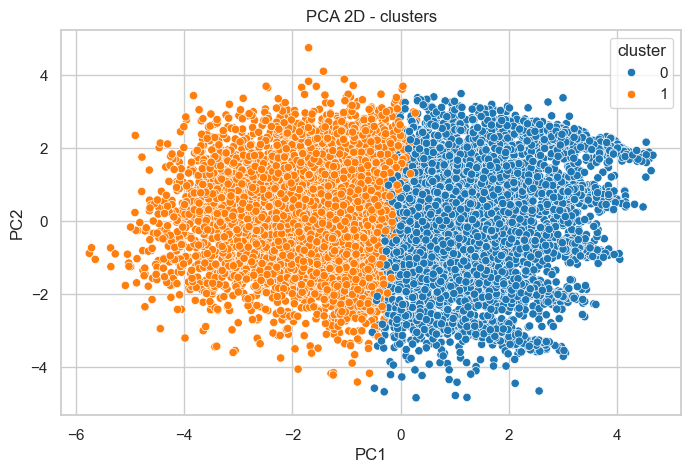

In [16]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_full)
vis_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
vis_df['cluster'] = labels
sns.scatterplot(data=vis_df, x='PC1', y='PC2', hue='cluster', palette='tab10')
plt.title('PCA 2D - clusters')
plt.show()

## 10. Respuestas al apartado de Análisis de resultados

1. Restricciones de los algoritmos: KMeans asume clusters esféricos y balanceados; Agglomerative depende del criterio de enlace; DBSCAN detecta ruido pero es sensible a eps/min_samples.
2. Criterios de selección: interpretabilidad, forma de clusters esperada, resistencia a ruido, y métrica (silueta).
3. Medir calidad: métricas intrínsecas (silueta), estabilidad y utilidad práctica.
4. Variación con algoritmos: revisar tabla comparativa y perfilado.
5. Interpretación: describir cada grupo con estadísticas (ver perfilado) y proponer recomendaciones para VuelaAlpes.

In [21]:
# Guardar resultados: etiquetas y tabla resumen
df_result.to_csv('resultados_clusters.csv', index=False)
pd.DataFrame(best_rows).to_csv('comparativa_modelos.csv', index=False)
print('Archivos guardados: resultados_clusters.csv, comparativa_modelos.csv')

Archivos guardados: resultados_clusters.csv, comparativa_modelos.csv
